# Time-based Pileup Discrimination
Computes time features from `contrib_times` and analyzes their separation power between HS and pileup.

**Assumes already defined:** `hits` (raw list-column df), `clusters_masked` (with `hs_cluster` bool column)

In [1]:
import sys
sys.path.insert(0, '/storage/agrp/barakma/PileupODD')

In [2]:

%load_ext autoreload
%autoreload 2

In [3]:
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import numpy as np

from huggingface_hub import HfFileSystem
import polars as pl

fs = HfFileSystem()

number_of_files = 1
event_type = 'ttbar_pu200'
number_of_hf_repo_files= 1000
# Load particles
particles_list = []
for i in range(number_of_files):
    file_path = f"datasets/CERN/ColliderML-Release-1/data/{event_type}_particles/train-{i:05d}-of-{number_of_hf_repo_files:05d}.parquet"
    with fs.open(file_path, "rb") as f:
        particles_list.append(pl.read_parquet(f, columns=[    'event_id',
    'particle_id',
    'vertex_primary',
    'pdg_id',
    'energy',
    'px',
    'py',
    'pz',
    'vx',
    'vy',
    'vz',
    'parent_id',
]))
particles = pl.concat(particles_list)

# Load calo_hits
calo_hits_list = []
for i in range(number_of_files):
    file_path = f"datasets/CERN/ColliderML-Release-1/data/{event_type}_calo_hits/train-{i:05d}-of-{number_of_hf_repo_files:05d}.parquet"
    with fs.open(file_path, "rb") as f:
        calo_hits_list.append(pl.read_parquet(f, columns=    ['event_id',
    'detector',
    'total_energy',
    'x',
    'y',
    'z',
    'contrib_particle_ids',
    'contrib_energies',
    'contrib_times',
]))
calo_hits = pl.concat(calo_hits_list)

# Load tracks
tracks_list = []
for i in range(number_of_files):
    file_path = f"datasets/CERN/ColliderML-Release-1/data/{event_type}_tracks/train-{i:05d}-of-{number_of_hf_repo_files:05d}.parquet"
    with fs.open(file_path, "rb") as f:
        tracks_list.append(pl.read_parquet(f))
tracks = pl.concat(tracks_list)

In [4]:
from primary.create_trainning_dataset_pileup import preprocess_for_model
preprocessed = preprocess_for_model(particles=particles, calo_hits=calo_hits, tracks=tracks)
clusters = preprocessed["calo_clusters"]
calo_hits = preprocessed["calo_hits"]
deps  = preprocessed['target_particles_deps']


[PREPROCESS START]
RAM: 7102.41 MB
[CASTING] Converting Float64 to Float32...
[EXTRAPOLATED FEATURES] Calculating extrapolated track features...
[EXTRAPOLATED FEATURES DONE] RAM: 7143.71 MB
[PROCESSING TRACKS] Filtering and processing tracks...
[CASTING DONE] RAM: 8083.45 MB
[ORPHAN MASK] Adding orphan mask...
Computing parent existence mask...
[ORPHAN MASK DONE] RAM: 8148.42 MB
[CALO MASK] Adding created inside calo mask...
[CALO MASK DONE] RAM: 8151.35 MB
[TRACK MASK] Adding particle have track mask...
[TRACK MASK DONE] RAM: 8155.93 MB
[ETA PHI PT] Adding eta, phi, pt...
[ETA PHI PT DONE] RAM: 8166.79 MB
[PARENT MASK] Getting particles id parent of inside calo particles...
Step 1: Building the Static Lookup Table (The Census)...
Step 2: initializing Active Paths for Depositors only...


/storage/agrp/barakma/PileupODD/primary/preprocessing.py:194: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  if "is_parent_missing" in df.columns:


Converged after 10 iterations on 398524 depositors.
[PARENT MASK DONE] RAM: 21117.43 MB
[TARGET PARTICLES MASK] Setting target particles mask...
Preparing lineage map...
Converged after 5 iterations.
Step 1: Preparing the Lookup Map (Context aware)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 6 iterations.
Step 4: Final validation...
Step 1: Preparing the Lookup Map (The World + Stop Signs)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 12 iterations.
Step 4: Final validation...
[TARGET PARTICLES MASK DONE] RAM: 21155.77 MB
[PROCESSING TRACKS DONE] RAM: 21155.77 MB
[CLUE CLUSTERING] Running CLUE clustering...


Clustering events: 100%|███████████████████████████████████████████████████| 100/100 [00:28<00:00,  3.54it/s]


[CLUE CLUSTERING DONE] RAM: 65850.47 MB
[DEPOSITORS LIST] Creating depositors list...
[DEPOSITORS LIST DONE] RAM: 65870.47 MB
[TARGET PARTICLES AGG] Aggregating target particles...
[TARGET PARTICLES AGG DONE] RAM: 65870.54 MB
[PARTICLES FREED] RAM: 65870.54 MB
[CREATE CALO CLUSTERS] Creating calo clusters...
[CREATE CALO CLUSTERS DONE] RAM: 65871.82 MB
[CLUSTER IDX MAPPING] Creating cluster to cluster index mapping...
[CLUSTER IDX MAPPING DONE] RAM: 65871.88 MB
[BACKTRACK TO TARGET] Backtracking particles to target...
Step 1: Preparing the Lookup Map (The World + Stop Signs)...
Step 2: Initializing Active Paths from Source...
Step 3: Backtracking Loop...
Converged after 13 iterations.
Step 4: Final validation...
[BACKTRACK TO TARGET DONE] RAM: 65871.88 MB
[INTERMEDIATES FREED] RAM: 65871.88 MB
[CLUSTER PURITY] Computing cluster purity...
[CLUSTER PURITY DONE] RAM: 65871.95 MB
[CALO HITS FREED] RAM: 65871.95 MB
[FILTER ORPHANS] Filtering orphan particles and reindexing...
--- Orphan Fil

In [5]:
# Step 1: HS energy per (event_id, cluster)
hs_energy = (
    deps.select('event_id', 'total_energy_deps_in_cluster', 'particle_idx', 'cluster_idx')
    .explode('total_energy_deps_in_cluster', 'particle_idx', 'cluster_idx')
    .group_by('event_id', 'cluster_idx')
    .agg(pl.sum('total_energy_deps_in_cluster').alias('hs_energy'))
)

# Step 2: Explode clusters, join hs energy, apply mask
clusters_masked = (
    clusters
    .explode(
        'cluster_id', 'total_cluster_energy', 'hcal_energy',
        'sigma_eta', 'sigma_phi', 'sigma_rho',
        'cluster_phi', 'cluster_eta', 'cluster_rho', 'hcal_fraction'
    )
    .join(
        hs_energy,
        left_on=['event_id', 'cluster_id'],
        right_on=['event_id', 'cluster_idx'],
        how='left'
    )
    .with_columns(pl.col('hs_energy').fill_null(0.0))
    .with_columns(
        (
            (pl.col('hs_energy') > 0.150) &                                      # HS energy > 150 MeV
            (pl.col('hs_energy') / pl.col('total_cluster_energy') > 0.05)      # HS fraction > 5%
        ).alias('hs_cluster')
    )
)

In [ ]:
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

labels = {True: 'HS', False: 'PU'}
colors = {True: 'steelblue', False: 'tomato'}

## 1. Hit-level time features

After exploding the outer list (one row per hit), `contrib_times`/`contrib_energies` are `list[f32]` contributions from each particle to that hit.

| Feature | Definition |
|---|---|
| `t_ew` | energy-weighted mean: Σ(eᵢtᵢ)/Σeᵢ |
| `t_std` | time spread among contributors: σ(tᵢ) |
| `t_min` | earliest contributor time |

In [13]:
hs_label = clusters_masked.select('event_id', 'cluster_id', 'hs_cluster')
from primary.calibration import CALIBRATION
_scalar_cols = [
    'event_id', 'detector', 'total_energy', 'x', 'y', 'z',
    'cluster_id', 'cluster_cx', 'cluster_cy', 'cluster_cz',
    'hs_cluster',
]

hits_flat = (
    calo_hits
    .explode(
        'detector', 'total_energy', 'x', 'y', 'z',
        'contrib_particle_ids', 'contrib_energies', 'contrib_times',
        'cluster_id', 'cluster_cx', 'cluster_cy', 'cluster_cz', 'detector'
    )
    .join(hs_label, on=['event_id', 'cluster_id'], how='left')
    .join(CALIBRATION.select('detector', 'calib_factor'), on='detector', how='left')
    .with_columns(
        pl.col('hs_cluster').fill_null(False),
    )
    .with_row_index('_hit_idx')
    # Second explode: flatten contributions per hit
    .explode('contrib_times', 'contrib_energies', 'contrib_particle_ids')
    .with_columns(
        (pl.col('contrib_energies') * pl.col('calib_factor')).alias('contrib_energies')
    )
    .group_by('_hit_idx', maintain_order=True)
    .agg(
        *[pl.col(c).first() for c in _scalar_cols],
        pl.col('contrib_particle_ids'),
        pl.col('contrib_energies'),
        pl.col('contrib_times'),
        pl.col('contrib_times').min().alias('t_min'),
        pl.col('contrib_times').std(ddof=0).fill_null(0.0).alias('t_std'),
        pl.when(pl.col('contrib_energies').sum() > 0)
          .then(
              (pl.col('contrib_times') * pl.col('contrib_energies')).sum()
              / pl.col('contrib_energies').sum()
          )
          .otherwise(None)
          .alias('t_ew'),
    )
    .drop('_hit_idx')
)

## 2. Cluster-level aggregation

Added cluster features:
- `max_hit_energy`: maximum single-hit energy in the cluster [MeV]
- `hit_count`: number of hits in the cluster
- `energy_density`: average hit energy in the cluster, `cluster_energy / hit_count` [MeV/hit]
- `cluster_alpha`: `ln Σ_j (pT_j / ΔR_ij)^2` computed per event from cluster neighbors

In [35]:
cluster_time = (
    hits_flat
    .group_by('event_id', 'cluster_id')
    .agg([
        ((pl.col('t_ew') * pl.col('total_energy')).sum()
          / pl.col('total_energy').sum()).alias('cluster_t_ew'),
        pl.col('t_ew').std().alias('cluster_t_std'),
        pl.col('t_ew').min().alias('cluster_t_min'),
        pl.col('t_min').min().alias('cluster_t_earliest'),
        pl.col('total_energy').sum().alias('cluster_energy'),
        pl.col('total_energy').max().alias('max_hit_energy'),
        pl.len().alias('hit_count'),
        pl.col('hs_cluster').first(),
    ])
    .with_columns(
        pl.when(pl.col('hit_count') > 0)
        .then(pl.col('cluster_energy') / pl.col('hit_count'))
        .otherwise(None)
        .alias('energy_density')
    )
)

# Add cluster eta/phi for cluster-level geometric features.
cluster_geom = (
    clusters_masked
    .select('event_id', 'cluster_id', 'cluster_eta', 'cluster_phi')
    .unique(subset=['event_id', 'cluster_id'])
)

cluster_time = (
    cluster_time
    .join(cluster_geom, on=['event_id', 'cluster_id'], how='left')
    .with_columns(
        (pl.col('cluster_energy') / pl.col('cluster_eta').cosh()).alias('cluster_pt')
    )
)

# alpha_i = ln sum_{j in DeltaR<0.3} (pT_j / DeltaR_ij)^2, computed within each event.
def _compute_cluster_alpha_per_event(pdf_event):
    eta = pdf_event['cluster_eta'].to_numpy(dtype=float)
    phi = pdf_event['cluster_phi'].to_numpy(dtype=float)
    pt = np.clip(pdf_event['cluster_pt'].to_numpy(dtype=float), 1e-12, None)

    dphi = np.abs(phi[:, None] - phi[None, :])
    dphi = np.where(dphi > np.pi, 2 * np.pi - dphi, dphi)
    deta = eta[:, None] - eta[None, :]
    dr = np.sqrt(deta * deta + dphi * dphi)

    # Exclude self and keep only local neighborhood.
    np.fill_diagonal(dr, np.inf)
    local_mask = dr < 0.1
    dr_safe = np.maximum(dr, 1e-3)

    contrib = ((pt[None, :] / dr_safe) ** 2) * local_mask
    alpha = np.log(contrib.sum(axis=1) + 1e-12)

    out = pdf_event[['cluster_id']].copy()
    out['event_id'] = pdf_event.name
    out['cluster_alpha'] = alpha
    return out[['event_id', 'cluster_id', 'cluster_alpha']]

alpha_pdf = (
    cluster_time
    .select('event_id', 'cluster_id', 'cluster_eta', 'cluster_phi', 'cluster_pt')
    .to_pandas()
    .groupby('event_id', group_keys=False)
    .apply(_compute_cluster_alpha_per_event, include_groups=False)
    .reset_index(drop=True)
)

cluster_time = cluster_time.join(
    pl.from_pandas(alpha_pdf),
    on=['event_id', 'cluster_id'],
    how='left',
)

cluster_time.filter(pl.col('hs_cluster')==True).sort('event_id')

event_id,cluster_id,cluster_t_ew,cluster_t_std,cluster_t_min,cluster_t_earliest,cluster_energy,max_hit_energy,hit_count,hs_cluster,energy_density,cluster_eta,cluster_phi,cluster_pt,cluster_alpha
u32,i32,f64,f64,f64,f32,f32,f32,u32,bool,f64,f32,f32,f32,f64
0,2828,26.216988,null,26.216988,26.216988,0.003633,0.003633,1,true,0.003633,-1.984207,0.785398,0.00098,2.112719
0,2351,14.927267,0.431795,14.286809,14.286809,0.006785,0.002351,5,true,0.001357,-1.638121,-3.066381,0.002541,-0.049864
0,2108,17.607416,1.938148,16.459503,15.791862,0.126664,0.018987,55,true,0.002303,-3.133057,2.492565,0.01102,-27.631021
0,480,7.498224,null,7.498224,7.498224,0.003896,0.003896,1,true,0.003896,0.801343,3.068883,0.00291,1.13746
0,1511,14.083112,2.375973,11.867435,11.867435,0.021459,0.007289,23,true,0.000933,1.58743,1.972485,0.008423,0.617885
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
99,1374,17.940611,null,17.940611,17.940611,0.002386,0.002386,1,true,0.002386,2.558032,-1.532476,0.000367,-1.081332
99,410,9.165845,0.926645,6.834355,6.834355,0.015524,0.001593,31,true,0.000501,-1.09048,0.70156,0.009375,-0.834536
99,198,14.339027,0.197604,14.119673,14.119673,0.003819,0.002717,3,true,0.001273,-2.138935,-2.469988,0.000887,2.542174


## 3. Hit-level plots

## 4. Cluster-level plots

shape: (2, 2)
┌────────────┬────────────┐
│ hs_cluster ┆ n_clusters │
│ ---        ┆ ---        │
│ bool       ┆ u32        │
╞════════════╪════════════╡
│ false      ┆ 6382       │
│ true       ┆ 139        │
└────────────┴────────────┘


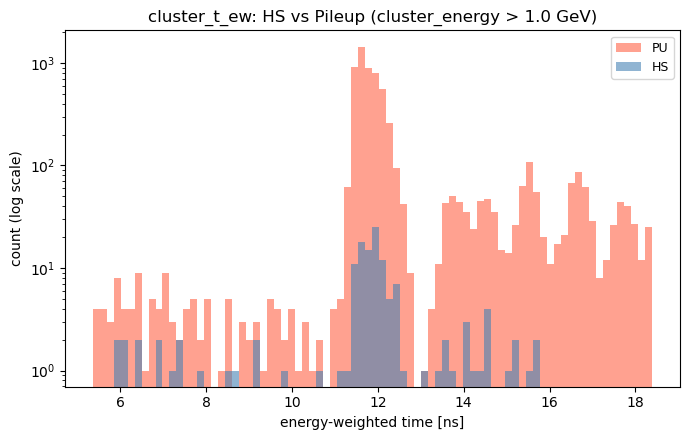

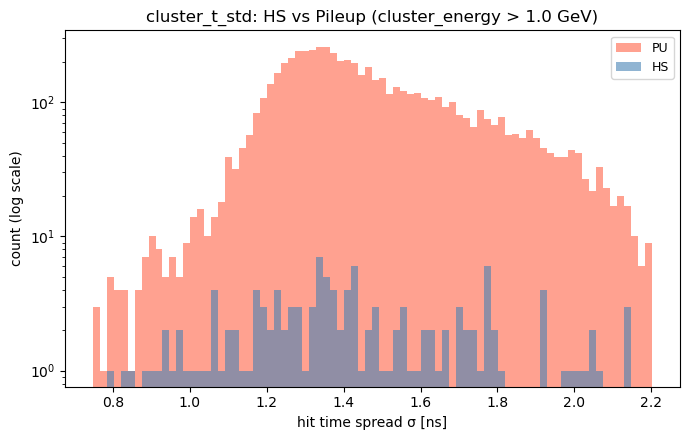

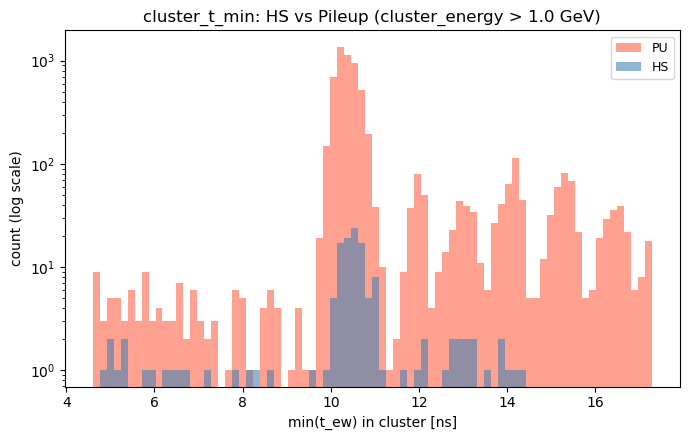

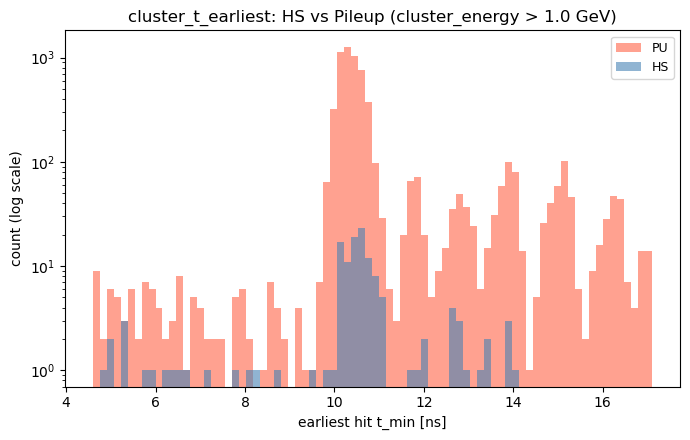

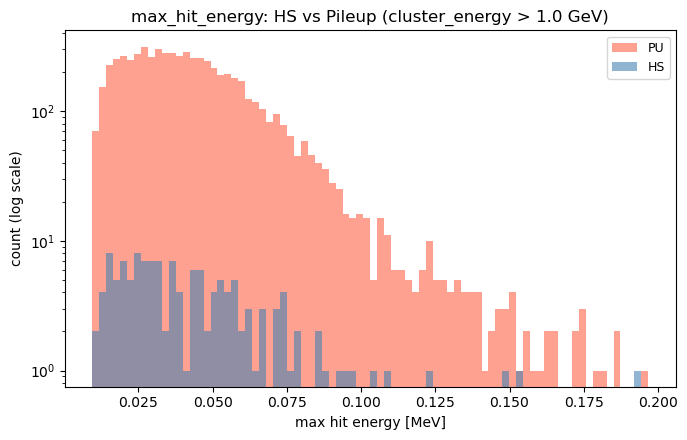

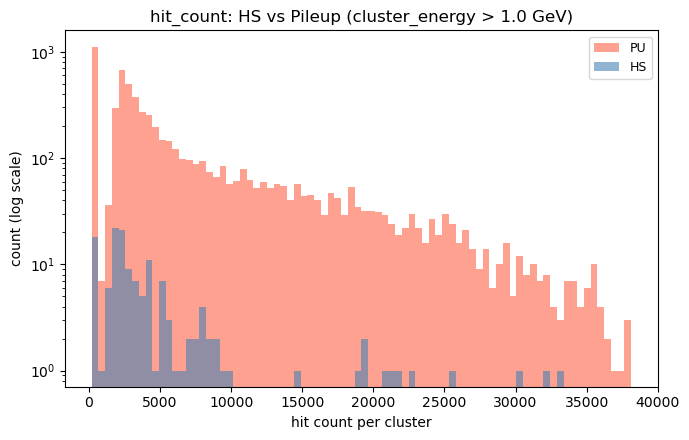

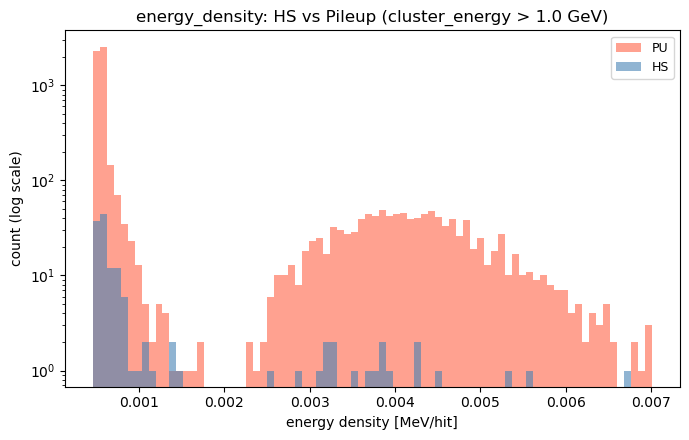

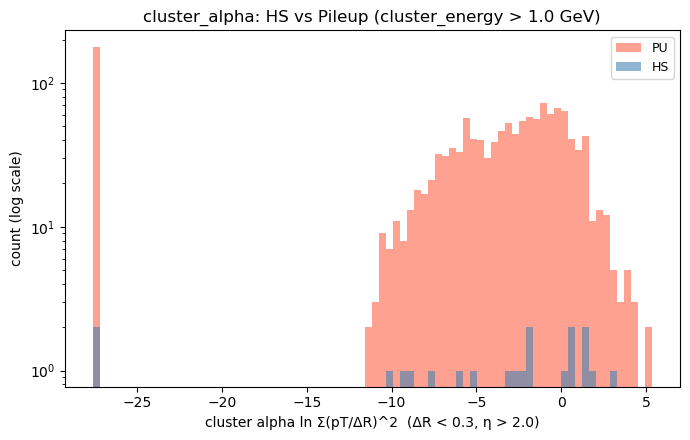

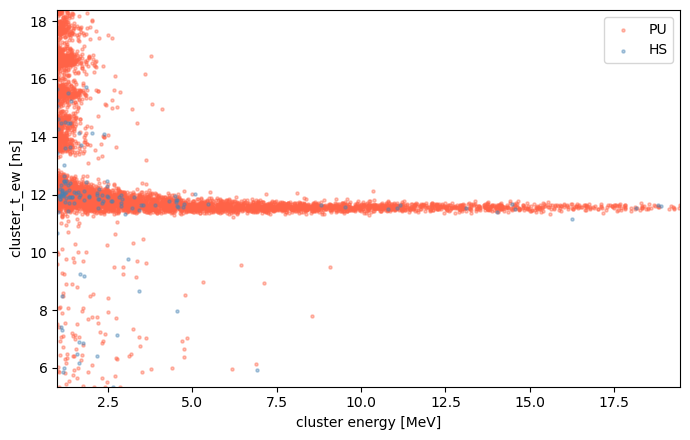

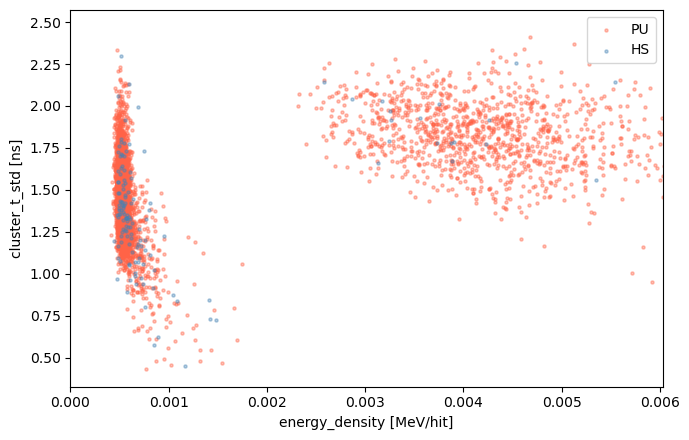

In [39]:

selected_event = None  # set to an int (e.g. 1) to inspect one event only
alpha_eta_cut = 2.5    # apply only in alpha plot (alpha is computed for all clusters)
energy_cut_gev = 1.0   # apply to all plots: keep only clusters above 1 GeV

if selected_event is None:
    cluster_plot_df = cluster_time
else:
    cluster_plot_df = cluster_time.filter(pl.col('event_id') == selected_event)

# Global cut for all plots.
cluster_plot_df = cluster_plot_df.filter(pl.col('cluster_energy') > energy_cut_gev)

count_summary = (
    cluster_plot_df
    .group_by('hs_cluster')
    .len()
    .rename({'len': 'n_clusters'})
    .sort('hs_cluster')
)
print(count_summary)

cl_pdf = cluster_plot_df.to_pandas()
if cl_pdf.empty:
    print(f'No clusters pass cluster_energy > {energy_cut_gev} GeV for the selected sample.')
else:
    cl_feats = [
        ('cluster_t_ew',       'energy-weighted time [ns]'),
        ('cluster_t_std',      'hit time spread σ [ns]'),
        ('cluster_t_min',      'min(t_ew) in cluster [ns]'),
        ('cluster_t_earliest', 'earliest hit t_min [ns]'),
        ('max_hit_energy',     'max hit energy [MeV]'),
        ('hit_count',          'hit count per cluster'),
        ('energy_density',     'energy density [MeV/hit]'),
        ('cluster_alpha',      'cluster alpha ln Σ(pT/ΔR)^2  (ΔR < 0.3, η > 2.0)'),
    ]

    # Plot each histogram in its own figure.
    for feat, xlabel in cl_feats:
        if feat == 'cluster_alpha':
            vals = cl_pdf.loc[cl_pdf['cluster_eta'] > alpha_eta_cut, feat].dropna()
        else:
            vals = cl_pdf[feat].dropna()

        if len(vals) == 0:
            continue

        lo, hi = np.nanpercentile(vals, [0.5, 99.5])

        fig, ax = plt.subplots(1, 1, figsize=(7, 4.5))
        for is_hs, grp in cl_pdf.groupby('hs_cluster'):
            grp_plot = grp
            if feat == 'cluster_alpha':
                grp_plot = grp_plot[grp_plot['cluster_eta'] > alpha_eta_cut]

            ax.hist(grp_plot[feat].dropna(), bins=80, alpha=0.6, density=False, log=True,
                    range=(lo, hi), label=labels[is_hs], color=colors[is_hs])

        ax.set_title(f'{feat}: HS vs Pileup (cluster_energy > {energy_cut_gev} GeV)')
        ax.set_xlabel(xlabel)
        ax.set_ylabel('count (log scale)')
        ax.legend(fontsize=9)
        plt.tight_layout()
        plt.show()

    # Scatter 1: time vs cluster energy
    fig, ax = plt.subplots(1, 1, figsize=(7, 4.5))
    for is_hs, grp in cl_pdf.groupby('hs_cluster'):
        ax.scatter(grp['cluster_energy'], grp['cluster_t_ew'], s=5, alpha=0.4,
                   label=labels[is_hs], color=colors[is_hs], rasterized=True)
    ax.set_xlabel('cluster energy [MeV]')
    ax.set_ylabel('cluster_t_ew [ns]')
    ax.set_xlim(energy_cut_gev, np.nanpercentile(cl_pdf['cluster_energy'], 99))
    ax.set_ylim(*np.nanpercentile(cl_pdf['cluster_t_ew'].dropna(), [0.5, 99.5]))
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Scatter 2: time spread vs energy density
    fig, ax = plt.subplots(1, 1, figsize=(7, 4.5))
    for is_hs, grp in cl_pdf.groupby('hs_cluster'):
        ax.scatter(grp['energy_density'], grp['cluster_t_std'], s=5, alpha=0.4,
                   label=labels[is_hs], color=colors[is_hs], rasterized=True)
    ax.set_xlabel('energy_density [MeV/hit]')
    ax.set_ylabel('cluster_t_std [ns]')
    ax.set_xlim(0, np.nanpercentile(cl_pdf['energy_density'], 99))
    ax.legend()
    plt.tight_layout()
    plt.show()

## 5. Correlation heatmap

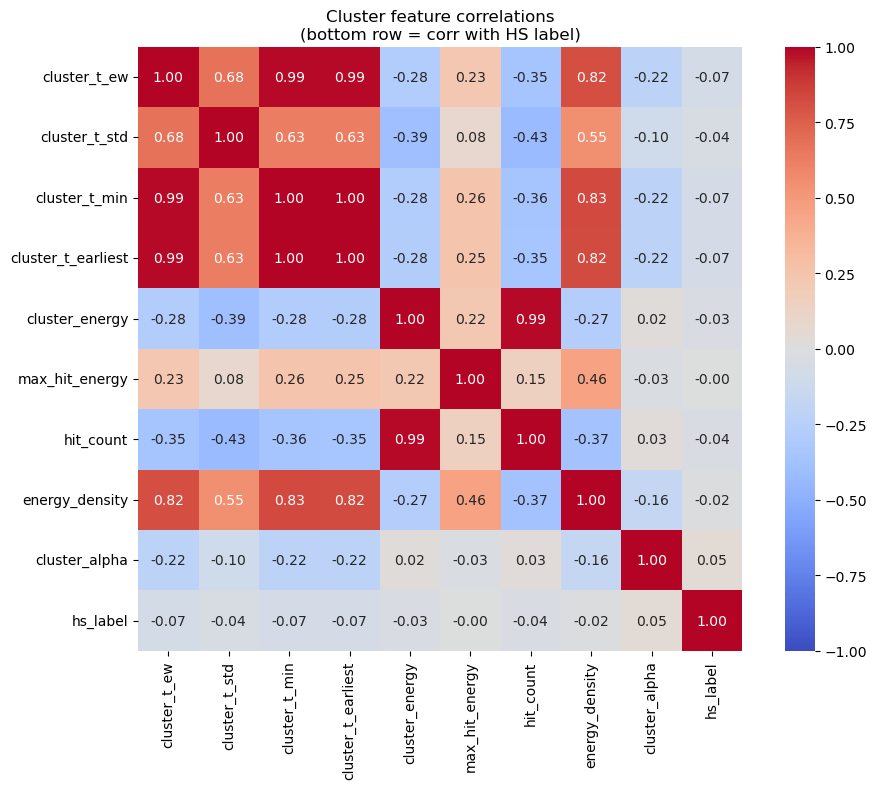

In [40]:
cl_pdf['hs_label'] = cl_pdf['hs_cluster'].astype(int)

corr_feats = [
    'cluster_t_ew', 'cluster_t_std', 'cluster_t_min',
    'cluster_t_earliest', 'cluster_energy', 'max_hit_energy',
    'hit_count', 'energy_density', 'cluster_alpha', 'hs_label'
]
corr = cl_pdf[corr_feats].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Cluster feature correlations\n(bottom row = corr with HS label)')
plt.tight_layout()
plt.show()